# 📸 Classificação de Imagens com MobileNetV3 (Timm)

Este notebook utiliza o modelo **`timm/mobilenetv3_small_100.lamb_in1k`** para classificar imagens localizadas na pasta `imagens/`.

### ✨ Objetivo
- Carregar o modelo MobileNetV3 pré-treinado.
- Processar imagens locais.
- Analisar as Top 5 categorias preditas com gráficos de confiança.

In [14]:
import torch
import timm
import os
import requests
from PIL import Image
import matplotlib.pyplot as plt
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

print(f"Torch version: {torch.__version__}")
print(f"Timm version: {timm.__version__}")

Torch version: 2.11.0+cu130
Timm version: 1.0.26


### 🛠 Configuração do Modelo e Labels

In [15]:
# Nome do modelo solicitado
MODEL_NAME = 'mobilenetv3_small_100.lamb_in1k'
IMAGE_DIR = 'imagens'

# Carregando o modelo pré-treinado
model = timm.create_model(MODEL_NAME, pretrained=True)
model.eval()  # Modo de inferência

# Obtendo as configurações de pré-processamento do modelo
config = resolve_data_config({}, model=model)
transform = create_transform(**config)

# Baixando os labels do ImageNet
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(LABELS_URL).text.splitlines()

print(f"Modelo '{MODEL_NAME}' carregado com sucesso!")
print(f"Configuração de entrada: {config['input_size']}")

Modelo 'mobilenetv3_small_100.lamb_in1k' carregado com sucesso!
Configuração de entrada: (3, 224, 224)


### 🔎 Verificação e Pesquisa de Categorias

In [16]:
print(f"Total de categorias carregadas: {len(labels)}")

def search_category(query):
    """Pesquisa categorias que contenham o termo digitado (case-insensitive)."""
    results = [label for label in labels if query.lower() in label.lower()]
    return results

# Exemplo de pesquisa: altere o termo abaixo para buscar outras categorias
termo_pesquisa = 'dog'
encontrados = search_category(termo_pesquisa)

print(f"\nCategorias encontradas com '{termo_pesquisa}': {len(encontrados)}")
for cat in encontrados[:10]:
    print(f"- {cat}")

Total de categorias carregadas: 1000

Categorias encontradas com 'dog': 10
- Maltese dog
- Old English sheepdog
- Shetland sheepdog
- Greater Swiss Mountain dog
- Bernese mountain dog
- French bulldog
- Eskimo dog
- African hunting dog
- dogsled
- hotdog


### 📊 Análise Detalhada (Top 5 com Gráfico)

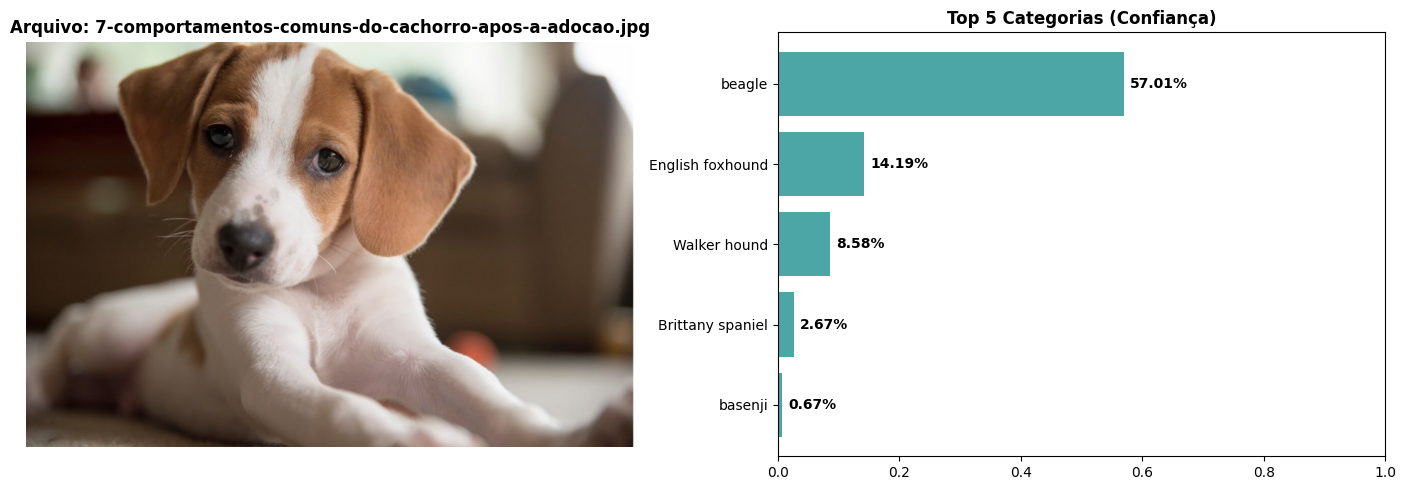

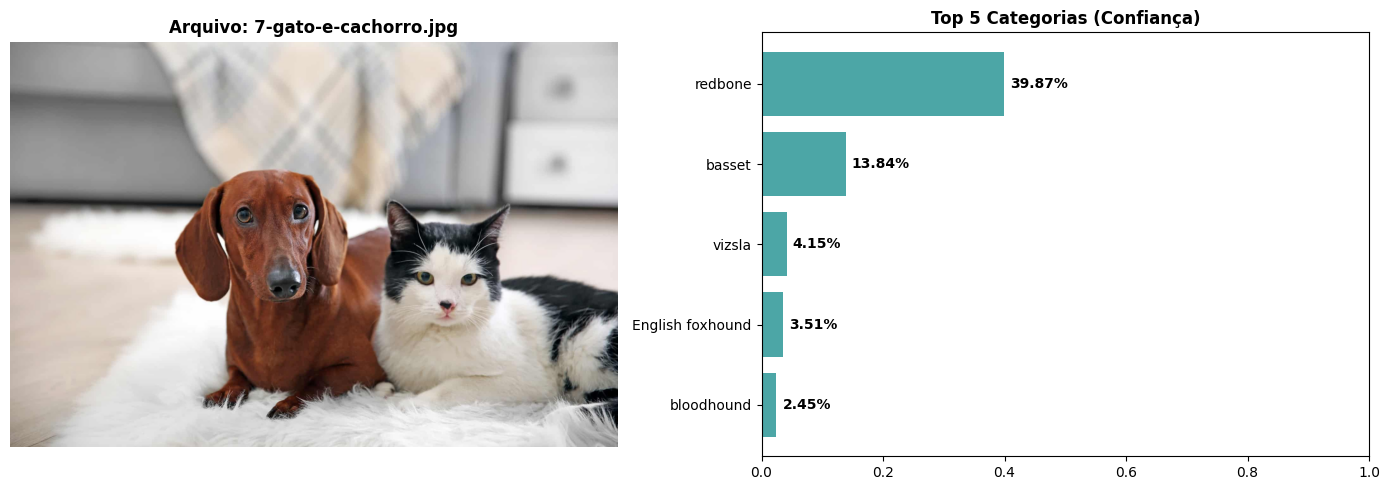

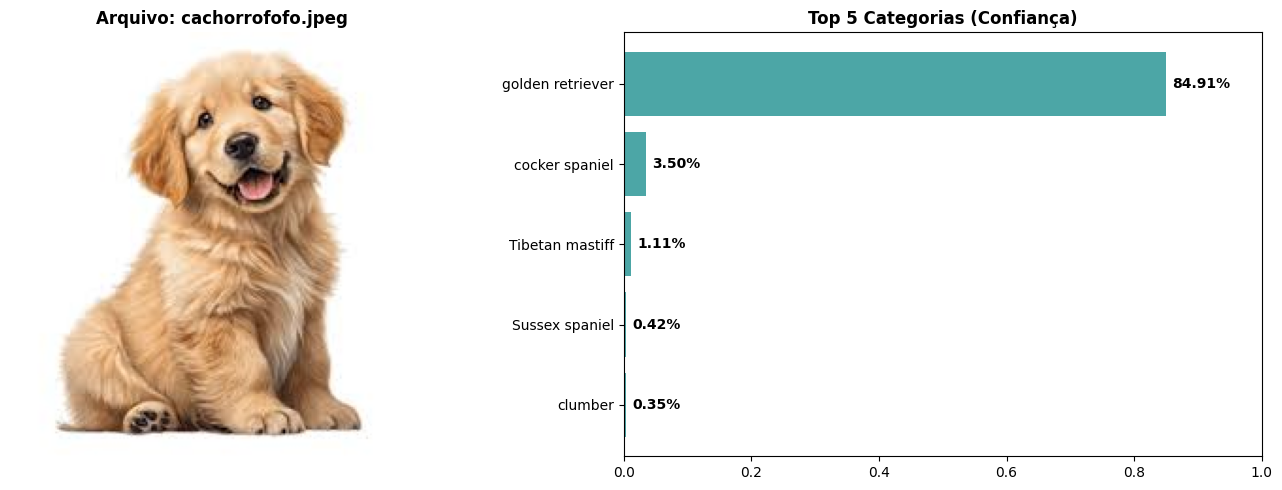

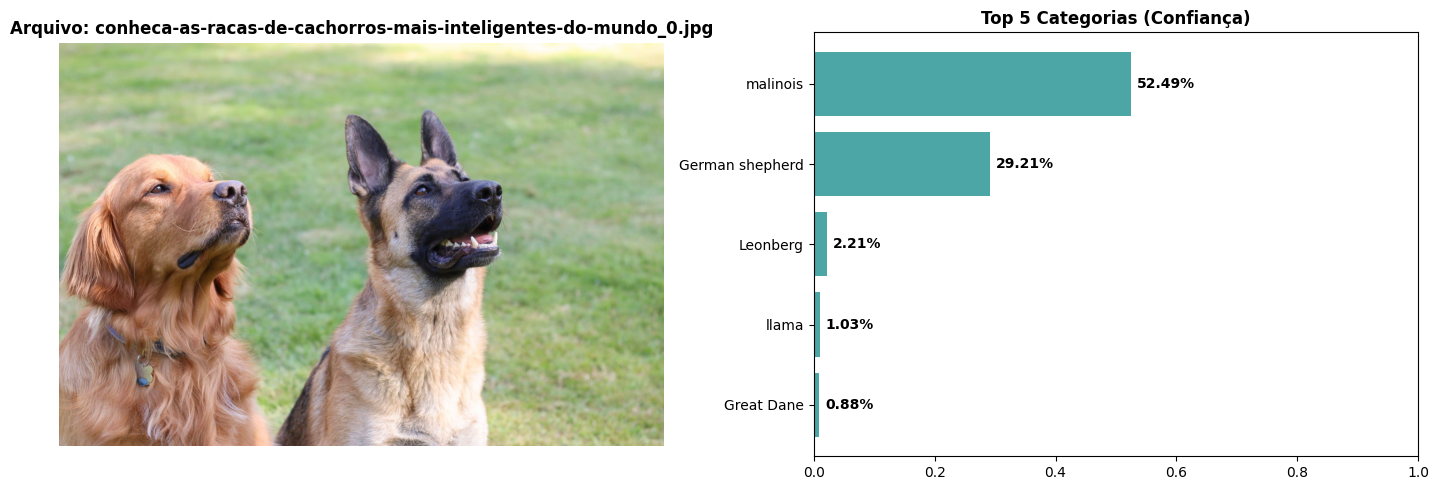

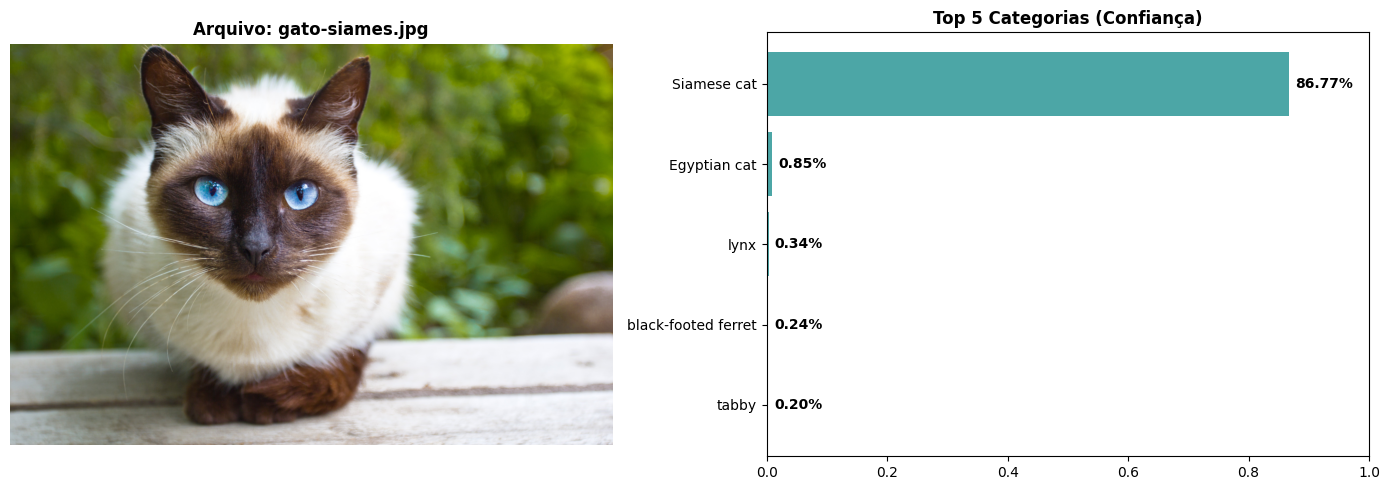

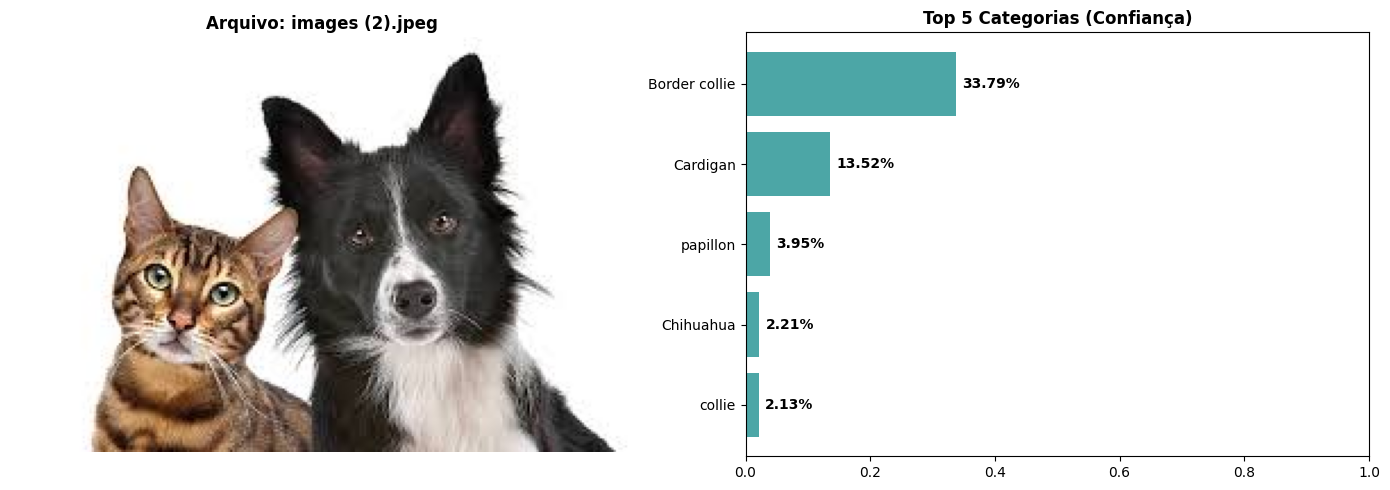

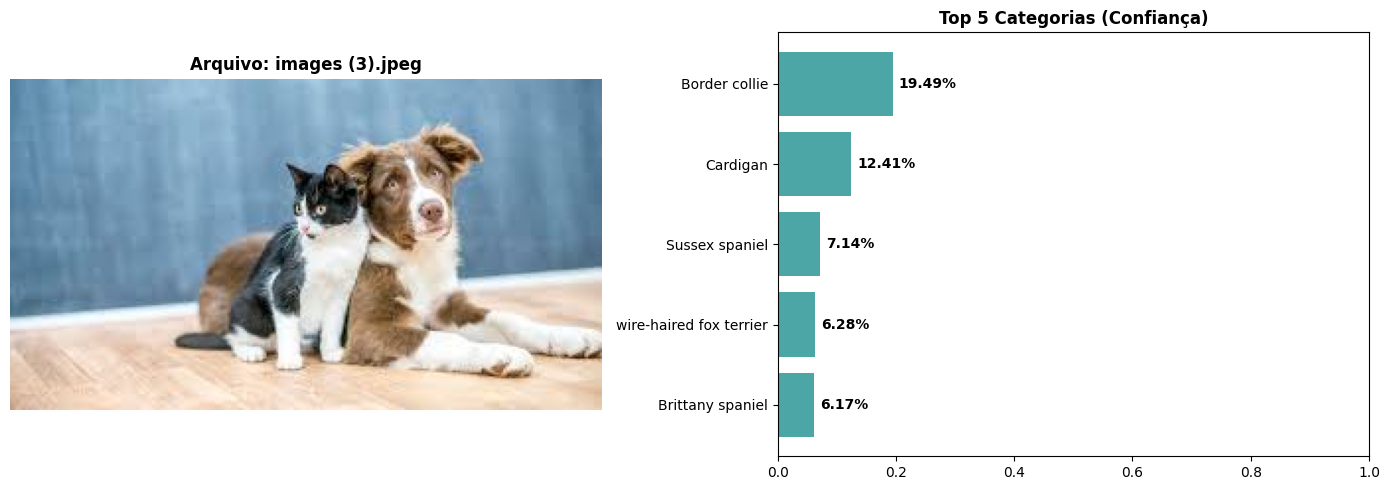

In [17]:
def classify_top5(image_path):
    """Retorna as top 5 categorias, suas probabilidades e a imagem original."""
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0)
    
    with torch.no_grad():
        output = model(tensor)
    
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_catid = torch.topk(probabilities, 5)
    
    top5_labels = [labels[idx.item()] for idx in top5_catid]
    top5_scores = [prob.item() for prob in top5_prob]
    
    return top5_labels, top5_scores, img

# Buscando imagens
valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(valid_extensions)])

for filename in image_files:
    path = os.path.join(IMAGE_DIR, filename)
    top_labels, top_scores, img = classify_top5(path)
    
    # Criando layout com 2 colunas: Imagem e Gráfico
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Coluna 1: Imagem
    ax1.imshow(img)
    ax1.set_title(f"Arquivo: {filename}", fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Coluna 2: Gráfico de Barras Horizontal
    y_pos = range(len(top_labels))
    bars = ax2.barh(y_pos, top_scores, color='teal', alpha=0.7)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(top_labels, fontsize=10)
    ax2.invert_yaxis()  # Maior probabilidade no topo
    ax2.set_xlim(0, 1.0) # Escala de 0% a 100%
    ax2.set_title("Top 5 Categorias (Confiança)", fontsize=12, fontweight='bold')
    
    # Adicionando rótulos de texto nas barras
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{width:.2%}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()